<a href="https://colab.research.google.com/github/praneethk002/AM11_Individual_Assignment/blob/main/ML_Final_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Setup & Data Collection


In [1]:
!pip install fredapi

In [72]:
import pandas as pd
import numpy as np
from fredapi.fred import Fred
import os
np.random.seed(42)

In [63]:
#FRED DATA FOR YIELD SETUP
from google.colab import userdata
api_key = userdata.get('FRED_API_KEY')
fred = Fred(api_key)

In [46]:
series_ids = ['DGS2', 'DGS5', 'DGS10', 'DGS30', 'T10Y2Y']
df_yields_list = []

In [76]:
series_ids = ['DGS2', 'DGS5', 'DGS10', 'DGS30', 'T10Y2Y']
yield_series_dict = {}

for series_id in series_ids:
    # Fetch data for each series.
    # observation_start and observation_end can help filter the initial fetch.
    series_data = fred.get_series(series_id, observation_start='2000-01-01', observation_end='2025-12-31')
    if series_data is not None and not series_data.empty:
        # Store each series in a dictionary with its series_id as the key
        yield_series_dict[series_id] = series_data

# Concatenate all fetched series into a single DataFrame using the dictionary
if yield_series_dict:
    df_yields = pd.DataFrame(yield_series_dict)

    # Resample to monthly and take the last business day of the month as per spec
    # Using 'ME' for month-end frequency, for consistency with yfinance and modern pandas.
    df_yields = df_yields.resample('ME').last()

    # Filter to the specified date range 2000-2025
    df_yields = df_yields[(df_yields.index.year >= 2000) & (df_yields.index.year <= 2025)]

    # The spec states "No NaNs in the core period".
    # For now, we will drop rows that are entirely NaN, which might happen at boundaries.
    # More sophisticated NaN handling (e.g., forward fill, interpolation) might be needed
    # depending on what "core period" means for NaN absence.
    df_yields = df_yields.dropna(how='all')

    print("df_yields head:")
    print(df_yields.head())
    print("\ndf_yields info:")
    print(df_yields.info())
else:
    df_yields = pd.DataFrame()
    print("No data fetched for the specified series. Check API key and series IDs.")

df_yields head:
            DGS2  DGS5  DGS10  DGS30  T10Y2Y
2000-01-31  6.61  6.71   6.68   6.49    0.07
2000-02-29  6.53  6.61   6.42   6.15   -0.11
2000-03-31  6.50  6.32   6.03   5.84   -0.47
2000-04-30  6.68  6.56   6.23   5.97   -0.45
2000-05-31  6.69  6.54   6.29   6.02   -0.40

df_yields info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 312 entries, 2000-01-31 to 2025-12-31
Freq: ME
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS2    312 non-null    float64
 1   DGS5    312 non-null    float64
 2   DGS10   312 non-null    float64
 3   DGS30   312 non-null    float64
 4   T10Y2Y  312 non-null    float64
dtypes: float64(5)
memory usage: 14.6 KB
None


In [48]:
df_yields

,DGS2,DGS5,DGS10,DGS30,T10Y2Y
2000-01-31,6.61,6.71,6.68,6.49,0.07
2000-02-29,6.53,6.61,6.42,6.15,-0.11
2000-03-31,6.50,6.32,6.03,5.84,-0.47
2000-04-30,6.68,6.56,6.23,5.97,-0.45
2000-05-31,6.69,6.54,6.29,6.02,-0.40
...,...,...,...,...,...
2025-08-31,3.59,3.68,4.23,4.92,0.64
2025-09-30,3.60,3.74,4.16,4.73,0.56
2025-10-31,3.60,3.71,4.11,4.67,0.51
2025-11-30,3.47,3.59,4.02,4.67,0.55


In [49]:
df_yields.dropna(how='all')

,DGS2,DGS5,DGS10,DGS30,T10Y2Y
2000-01-31,6.61,6.71,6.68,6.49,0.07
2000-02-29,6.53,6.61,6.42,6.15,-0.11
2000-03-31,6.50,6.32,6.03,5.84,-0.47
2000-04-30,6.68,6.56,6.23,5.97,-0.45
2000-05-31,6.69,6.54,6.29,6.02,-0.40
...,...,...,...,...,...
2025-08-31,3.59,3.68,4.23,4.92,0.64
2025-09-30,3.60,3.74,4.16,4.73,0.56
2025-10-31,3.60,3.71,4.11,4.67,0.51
2025-11-30,3.47,3.59,4.02,4.67,0.55


In [74]:
# import yfinance as yf # Already imported in an earlier cell
# import pandas as pd # Already imported in an earlier cell

# Define the list of ticker symbols for the sector ETFs and SPY
sector_tickers = ['XLF', 'XLE', 'XLK', 'XLU', 'XLP', 'XLY', 'XLV', 'XLI', 'XLB', 'SPY']

# Note: XLRE (Real Estate sector ETF) was intentionally excluded from this analysis.
# It launched in 2015, which is later than the start of our analysis period (2000),
# leading to significant data gaps if included.

# Fetch monthly adjusted close prices from Yahoo Finance
# Setting the start date slightly before 2000-01-01 to ensure the first month's return (Jan 2000) can be calculated.
# Explicitly set auto_adjust=False to ensure 'Adj Close' column is available.
data = yf.download(sector_tickers, start='1999-12-01', end='2025-12-31', interval='1mo', auto_adjust=False)

# Extract only the 'Adj Close' prices for all tickers
adj_close_prices = data['Adj Close']

# Convert index to month-end dates for proper alignment with df_yields.
# yfinance with '1mo' interval typically returns dates as the first day of the month.
adj_close_prices.index = adj_close_prices.index + pd.offsets.MonthEnd(0)

# Calculate monthly returns (percentage change).
# Keeping returns as decimals internally; they can be multiplied by 100 for display if needed.
df_sectors = adj_close_prices.pct_change()

# Drop the first row which will contain NaN values due to pct_change() (the return for the first month fetched).
df_sectors = df_sectors.dropna()

# Filter to the specified date range 2000-2025.
df_sectors = df_sectors[(df_sectors.index.year >= 2000) & (df_sectors.index.year <= 2025)]

# Ensure the index is a DatetimeIndex and its frequency is explicitly set to 'ME' (Month End).
# This helps ensure consistency with df_yields.
df_sectors = df_sectors.asfreq('ME')

print("df_sectors head:")
print(df_sectors.head())
print("\ndf_sectors info:")
print(df_sectors.info())

[*********************100%***********************]  10 of 10 completed


df_sectors head:
Ticker           SPY       XLB       XLE  ...       XLU       XLV       XLY
Date                                      ...                              
2000-01-31 -0.047454 -0.118590  0.011047  ... -0.011503 -0.019586 -0.123148
2000-02-29 -0.015226 -0.100469 -0.042334  ... -0.121538 -0.065387 -0.055715
2000-03-31  0.094133  0.098288  0.120669  ...  0.101030  0.089950  0.139295
2000-04-30 -0.032668 -0.030927 -0.011625  ...  0.073400 -0.011717 -0.018912
2000-05-31 -0.015722 -0.031557  0.117424  ... -0.002193 -0.026804 -0.053980

[5 rows x 10 columns]

df_sectors info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 312 entries, 2000-01-31 to 2025-12-31
Freq: ME
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     312 non-null    float64
 1   XLB     312 non-null    float64
 2   XLE     312 non-null    float64
 3   XLF     312 non-null    float64
 4   XLI     312 non-null    float64
 5   XLK     312 n

In [52]:
df_sectors

Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2000-01-31,-4.745405,-11.858994,1.104709,-2.602321,-7.815602,-6.146663,1.176646,-1.150326,-1.958616,-12.314835
2000-02-29,-1.522612,-10.046923,-4.233410,-10.704589,-5.517273,10.506820,-11.701356,-12.153784,-6.538698,-5.571519
2000-03-31,9.413312,9.828774,12.066900,17.829992,13.686125,8.389247,3.427258,10.103007,8.995038,13.929472
2000-04-30,-3.266820,-3.092662,-1.162522,1.336376,1.653852,-9.184741,5.639942,7.340036,-1.171687,-1.891242
2000-05-31,-1.572220,-3.155685,11.742432,2.232098,-0.421913,-10.397739,7.132881,-0.219347,-2.680407,-5.398032
...,...,...,...,...,...,...,...,...,...,...
2025-08-31,2.051954,5.186357,3.646371,3.093378,0.000000,-0.110382,1.253429,-1.575806,5.366871,4.656099
2025-09-30,3.275714,-2.882521,-1.161638,-0.222270,1.460429,7.395696,-2.983406,3.427415,1.266095,3.408989
2025-10-31,2.667587,-3.953874,-0.512571,-2.464455,0.953530,6.814172,-1.998925,2.854897,4.124245,0.297598


In [69]:
print(f"Shape of df_yields: {df_yields.shape}")
print(f"Shape of df_sectors: {df_sectors.shape}")

if df_yields.shape[0] == df_sectors.shape[0]:
    print("Both DataFrames have the same number of rows.")
else:
    print("Warning: DataFrames have different numbers of rows. Check alignment.")


Shape of df_yields: (312, 5)
Shape of df_sectors: (312, 10)
Both DataFrames have the same number of rows.


In [70]:
print("Missing values in df_yields:")
print(df_yields.isnull().sum())

Missing values in df_yields:
DGS2      0
DGS5      0
DGS10     0
DGS30     0
T10Y2Y    0
dtype: int64


In [71]:
print(df_yields.index.equals(df_sectors.index))
print(df_sectors.isnull().sum())

True
Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64


Now, let's visualize the `T10Y2Y` spread to check for yield curve inversions and `XLF` monthly returns to observe the 2008 crash.

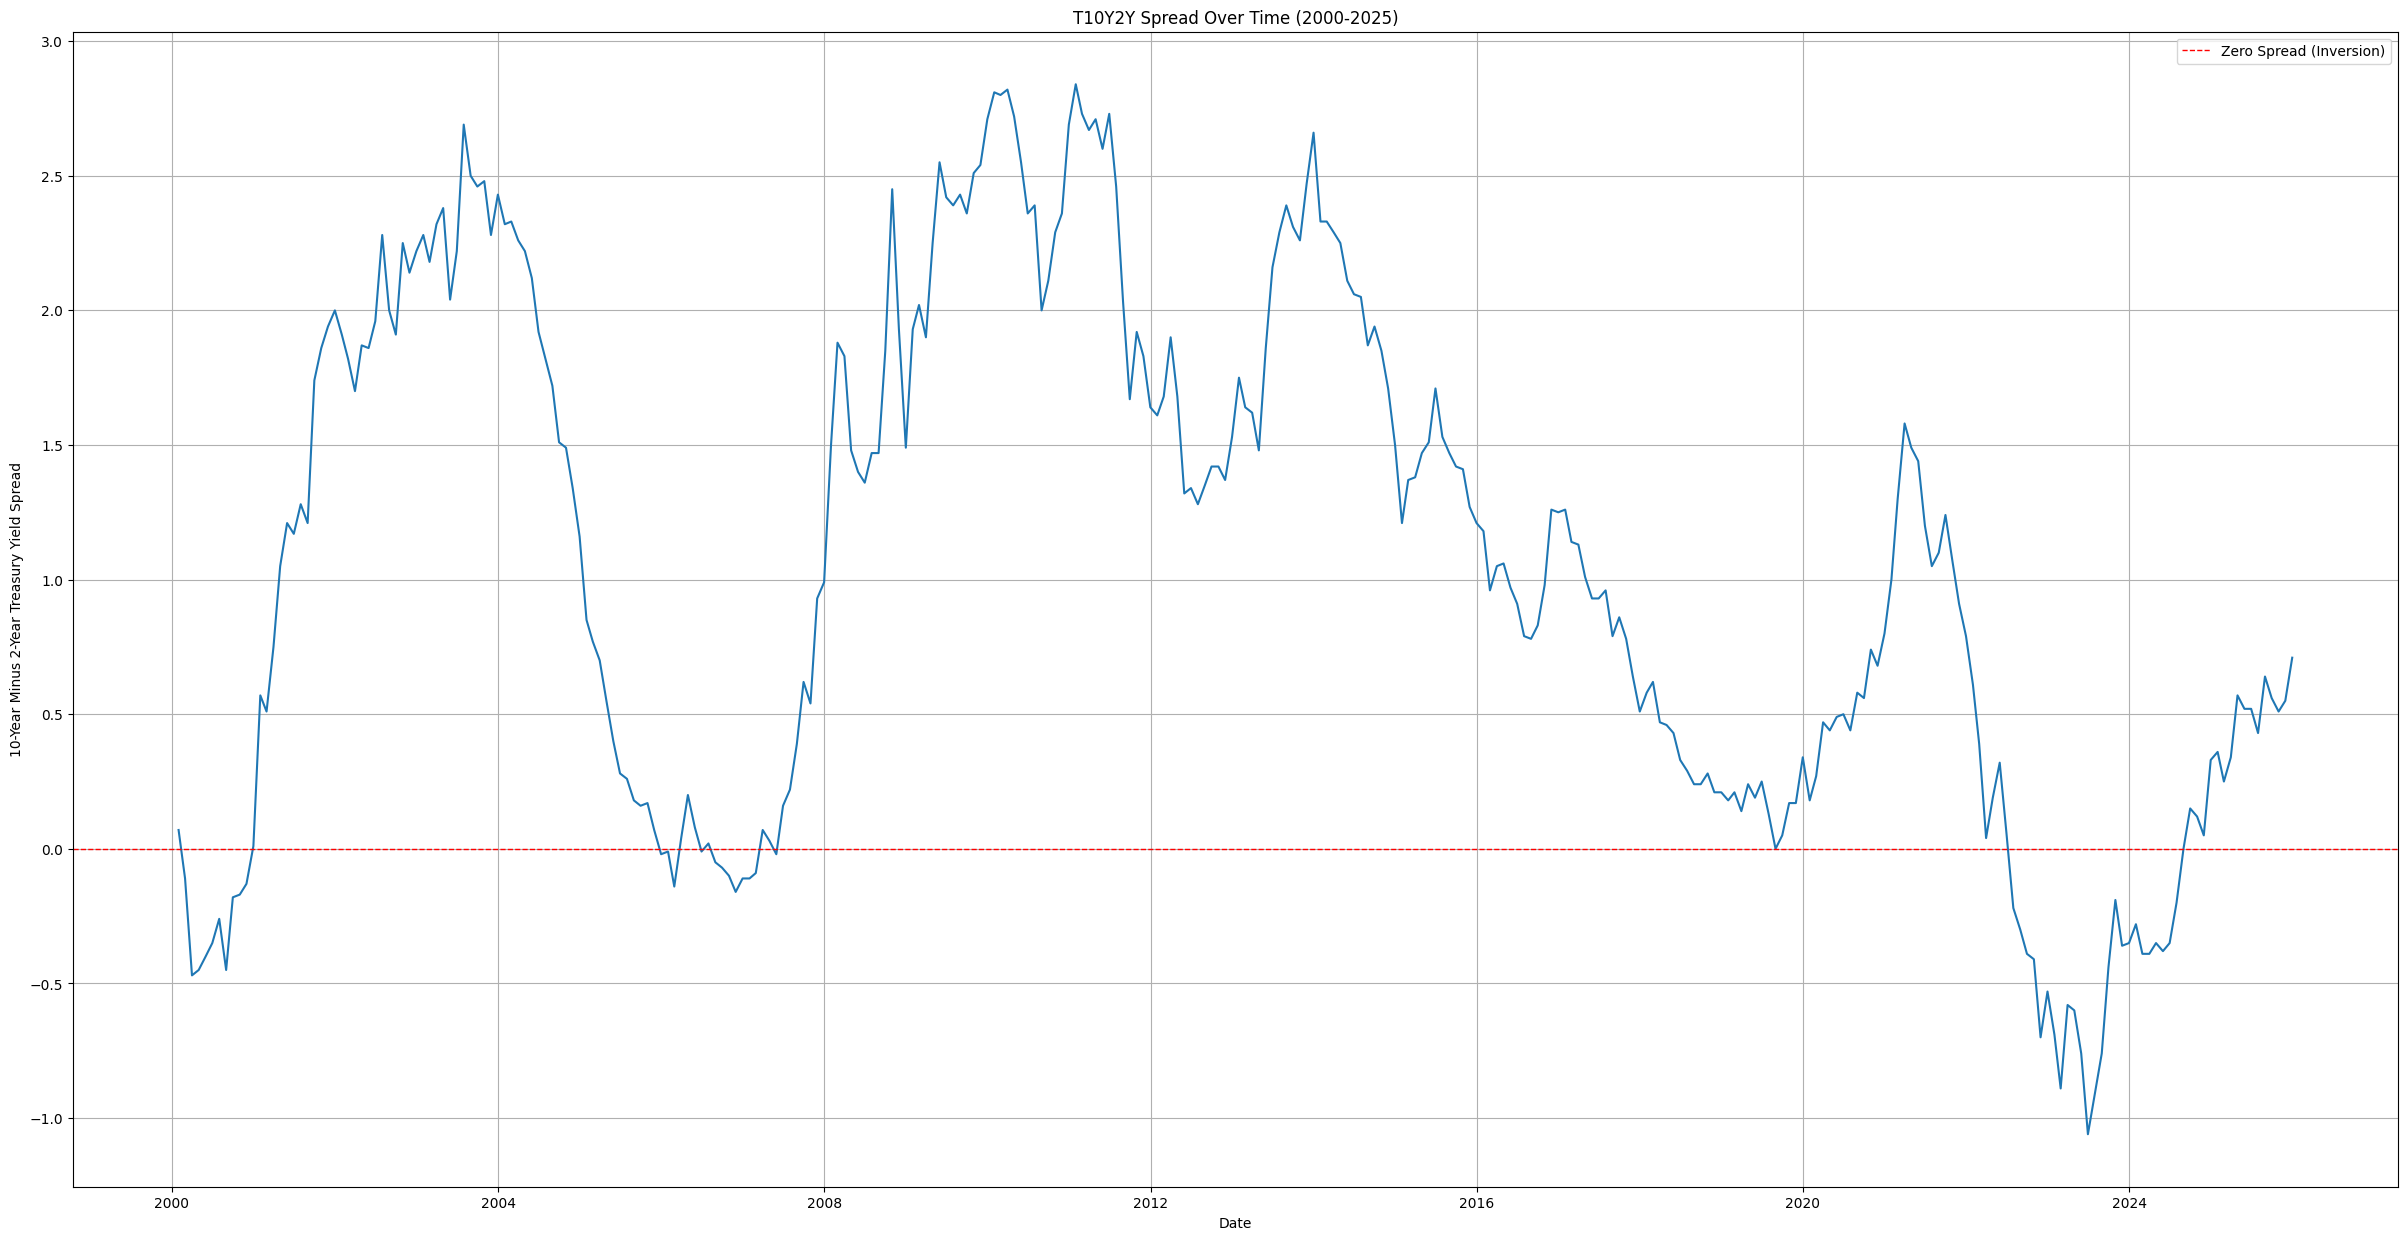

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 15)) # Increased figure size
sns.lineplot(x=df_yields.index, y=df_yields['T10Y2Y'])
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Spread (Inversion)')
plt.title('T10Y2Y Spread Over Time (2000-2025)')
plt.xlabel('Date')
plt.ylabel('10-Year Minus 2-Year Treasury Yield Spread')
plt.grid(True)
plt.legend()
plt.show()

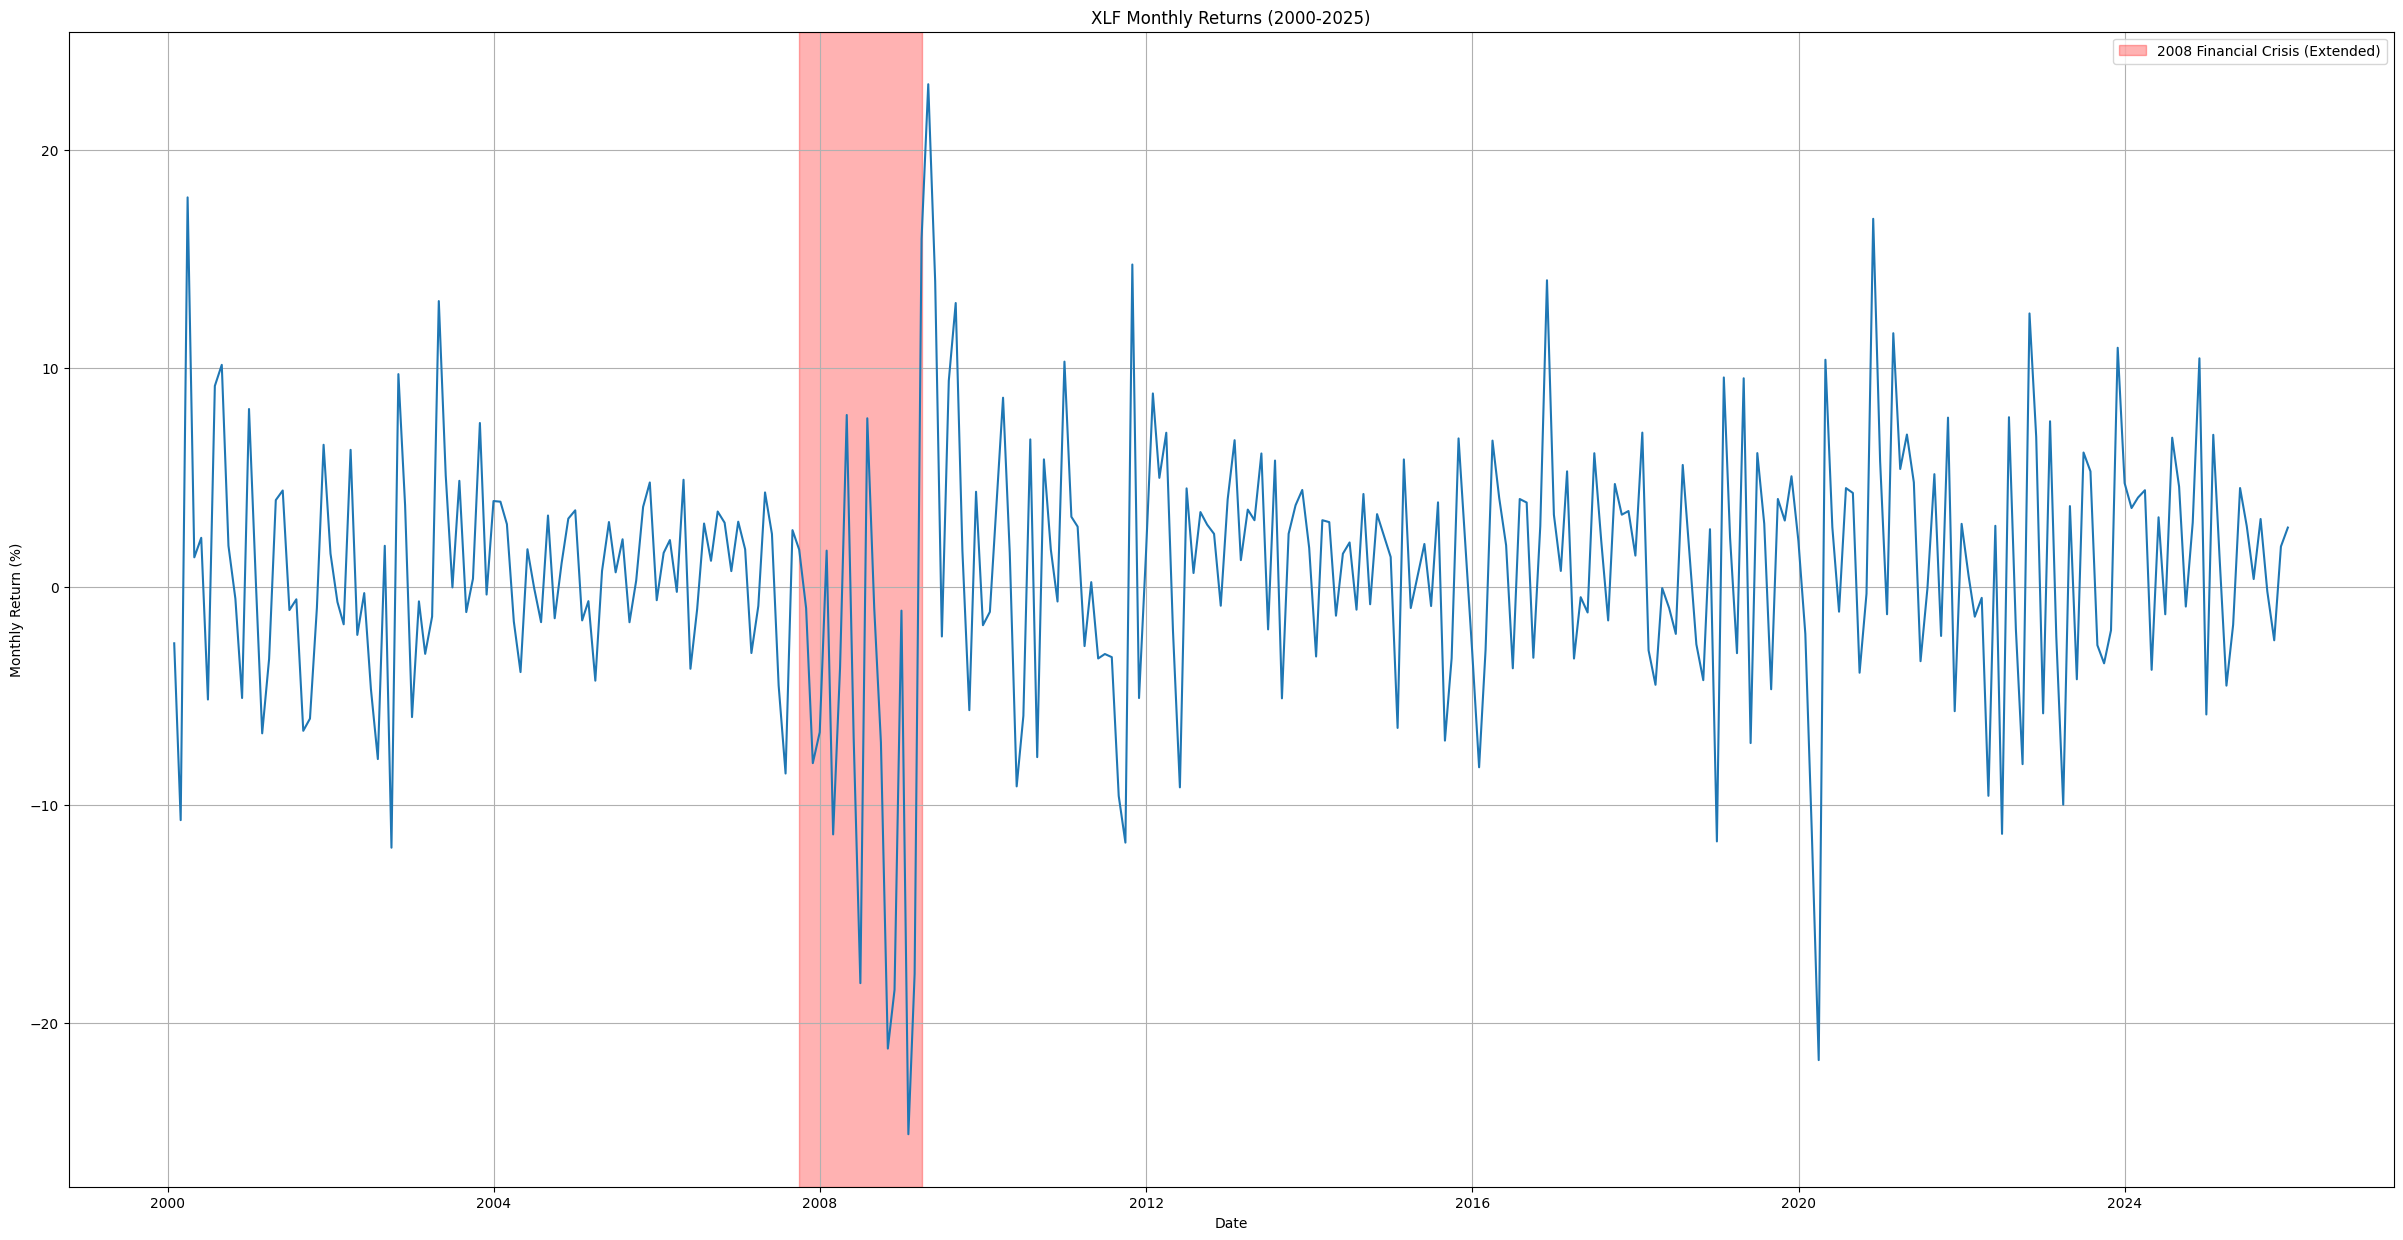

In [75]:
plt.figure(figsize=(30,15)) # Increased figure size
sns.lineplot(x=df_sectors.index, y=df_sectors['XLF'] * 100) # Multiply by 100 for display
plt.axvspan(pd.to_datetime('2007-10-01'), pd.to_datetime('2009-03-31'), color='red', alpha=0.3, label='2008 Financial Crisis (Extended)')
plt.title('XLF Monthly Returns (2000-2025)')
plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')
plt.grid(True)
plt.legend()
plt.show()